# Energy Consumption Forecasting Pipeline
### Single Meter | 30-min intervals | Short-term (XGBoost) + Long-term (N-HiTS)

**Pipeline:**
1. Data loading from MongoDB
2. Cleaning & resampling
3. Feature engineering
4. XGBoost - short-term (1–2 days)
5. N-HiTS (NeuralForecast) - long-term (full month ahead)
6. Plots: train/test, residuals, future forecast
7. Anomaly detection

## 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from typing import List

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import IsolationForest
import requests, time

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

print('All imports OK')

All imports OK


## 2. Data Loading

In [ ]:
from pymongo import MongoClient, DESCENDING

MONGO_URI = "string"
DB_NAME = "IOTDeviceMonitor"
COLLECTION = "FUTU00_DataMonitor"
METER_ID = "FUTU0000000004000002"
MODEL_DIR = "./models/"

client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION]

In [4]:
MODEL_DIR = "E:\Projects\IOT-AI-Implementation\models\M10"

In [5]:
query = {"EnergymeterId": METER_ID}
cursor = collection.find(query).sort("_id", DESCENDING)
raw = list(cursor)

df_raw = pd.DataFrame(raw)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

Raw shape: (980984, 6)


,_id,UID,RTC,A1,EnergymeterId,timestamp
0,69d8c5a49f2e531fa0d682eb,02,2026-04-10 08:08:00,345252.6400,FUTU0000000004000002,10-04-2026 15:10:52
1,69d8c56c9f2e531fa0d67d37,02,2026-04-10 08:07:00,345252.5600,FUTU0000000004000002,10-04-2026 15:09:56
2,69d8c52c9f2e531fa0d676f5,02,2026-04-10 08:06:00,345252.5200,FUTU0000000004000002,10-04-2026 15:08:52


## 3. Cleaning & Resampling

In [6]:
df = df_raw.copy()

# Rename
df = df.rename(columns={
    'A1': 'total_kwh',
    'RTC': 'rtc_timestamp',
    'EnergymeterId': 'meter_id'
})

# Sort (VERY IMPORTANT for time series)
df = df.sort_values(['meter_id', 'rtc_timestamp'])
                    
# Type conversion
df['total_kwh'] = pd.to_numeric(df['total_kwh'], errors='coerce')
df['rtc_timestamp'] = pd.to_datetime(df['rtc_timestamp'], errors='coerce')

# Drop rows with no timestamp or energy
df = df.dropna(subset=['rtc_timestamp', 'total_kwh'])

# Remove zeros (meter off / invalid)
df.loc[df['total_kwh'] == 0, 'total_kwh'] = np.nan
df = df.dropna()

# Resample to 1h
numeric_cols = df.select_dtypes(include=[np.number]).columns

df = (
    df.set_index('rtc_timestamp')
      .resample('1h')['total_kwh']
      .mean()
      .reset_index()
)

# Fill small gaps (up to 2 missing = 1 hour) via interpolation
# df = df.interpolate(method='time', limit=1)
# df = df.reset_index(name='total_kwh')

print(f"After cleaning: {df.shape}")
print(f"Date range: {df['rtc_timestamp'].min()} → {df['rtc_timestamp'].max()}")

After cleaning: (12989, 2)
Date range: 2024-10-16 04:00:00 → 2026-04-10 08:00:00


In [7]:
# REAL WEATHER DATA — Open-Meteo 
# Location: Ahmedabad, Gujarat, India  (23.02°N, 72.57°E)
WEATHER_COLS   = ['temperature', 'humidity', 'precipitation']
AHMEDABAD_LAT  = 23.0225
AHMEDABAD_LON  = 72.5714
_HOURLY_VARS   = "temperature_2m,relative_humidity_2m,precipitation"

def _fetch_openmeteo(start_date: str, end_date: str, *, base_url: str, lat: float = AHMEDABAD_LAT, lon: float = AHMEDABAD_LON) -> pd.DataFrame:
    """Low-level: fetch one chunk of hourly weather from Open-Meteo."""
    params = {
        "latitude": lat,  
        "longitude": lon,
        "hourly": _HOURLY_VARS,
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "auto",
    }
    resp = requests.get(base_url, params=params, timeout=120)
    resp.raise_for_status()
    h = resp.json()["hourly"]
    return pd.DataFrame({
        "rtc_timestamp": pd.to_datetime(h["time"]),
        "temperature": h["temperature_2m"],
        "humidity": h["relative_humidity_2m"],
        "precipitation": h["precipitation"],
    })


def fetch_historical_weather(timestamps: pd.Series, lat: float = AHMEDABAD_LAT, lon: float = AHMEDABAD_LON) -> pd.DataFrame:
    """
    Download real hourly weather for Ahmedabad from Open-Meteo.
    Uses the Archive API (ERA5 reanalysis) for historical dates
    and the Forecast API for the most recent ~5 days.
    """
    ts = pd.to_datetime(timestamps)
    start = ts.min().normalize()
    end   = ts.max().normalize()

    # ERA5 archive has a ~5-day lag; anything newer uses the Forecast API
    archive_cutoff = pd.Timestamp.now().normalize() - pd.Timedelta(days=6)

    chunks: list[pd.DataFrame] = []

    # Archive API (bulk of the history)
    if start <= archive_cutoff:
        chunk_end_limit = min(end, archive_cutoff)
        cursor = start
        while cursor <= chunk_end_limit:
            block_end = min(cursor + pd.Timedelta(days=89), chunk_end_limit)
            print(f"  [archive]  {cursor.date()} → {block_end.date()}")
            chunks.append(_fetch_openmeteo(
                str(cursor.date()), str(block_end.date()),
                base_url="https://archive-api.open-meteo.com/v1/archive",
                lat=lat, lon=lon))
            cursor = block_end + pd.Timedelta(days=1)
            time.sleep(0.3)          # polite rate-limiting for the free API

    # Forecast API (last few days not yet in ERA5)
    if end > archive_cutoff:
        recent_start = max(start, archive_cutoff + pd.Timedelta(days=1))
        print(f"  [forecast] {recent_start.date()} → {end.date()}")
        chunks.append(_fetch_openmeteo(
            str(recent_start.date()), str(end.date()),
            base_url="https://api.open-meteo.com/v1/forecast",
            lat=lat, lon=lon))

    weather_df = (pd.concat(chunks, ignore_index=True).drop_duplicates("rtc_timestamp").sort_values("rtc_timestamp").reset_index(drop=True))
    return weather_df


def fetch_forecast_weather(start_ts: pd.Timestamp, hours: int, lat: float = AHMEDABAD_LAT, lon: float = AHMEDABAD_LON) -> pd.DataFrame:
    """
    Download hourly weather *forecast* from Open-Meteo (up to 16 days ahead).
    Used by forecast_recursive() for the future weather horizon.
    """
    end_ts = start_ts + pd.Timedelta(hours=hours)
    return _fetch_openmeteo(
        str(start_ts.date()), str(end_ts.date()),
        base_url="https://api.open-meteo.com/v1/forecast",
        lat=lat, lon=lon)


In [8]:
# Fetch & merge
print("Fetching Ahmedabad weather from Open-Meteo …")
weather_df = fetch_historical_weather(df['rtc_timestamp'])
print(f"Weather DF: {weather_df.head()}")

df = df.merge(weather_df, on='rtc_timestamp', how='left')
for col in WEATHER_COLS:
    df[col] = df[col].interpolate(method='linear', limit=3)

print(f"After merging weather: {df.shape}  | weather cols: {WEATHER_COLS}")
df.head()

Fetching Ahmedabad weather from Open-Meteo …
  [archive]  2024-10-16 → 2025-01-13
  [archive]  2025-01-14 → 2025-04-13
  [archive]  2025-04-14 → 2025-07-12
  [archive]  2025-07-13 → 2025-10-10
  [archive]  2025-10-11 → 2026-01-08
  [archive]  2026-01-09 → 2026-04-08
  [archive]  2026-04-09 → 2026-04-10
Weather DF:         rtc_timestamp  temperature  humidity  precipitation
0 2024-10-16 00:00:00         26.0        91            0.0
1 2024-10-16 01:00:00         25.6        94            0.0
2 2024-10-16 02:00:00         25.5        94            0.0
3 2024-10-16 03:00:00         25.2        95            0.0
4 2024-10-16 04:00:00         25.1        95            0.0
After merging weather: (12989, 5)  | weather cols: ['temperature', 'humidity', 'precipitation']


,rtc_timestamp,total_kwh,temperature,humidity,precipitation
0,2024-10-16 04:00:00,79909.906296,25.1,95,0.0
1,2024-10-16 05:00:00,79932.895857,25.1,94,0.0
2,2024-10-16 06:00:00,79960.611061,26.2,87,0.0
3,2024-10-16 07:00:00,79978.275606,26.8,86,0.0
4,2024-10-16 08:00:00,80008.227973,28.2,82,0.0


## 3.1 Weather Data — Ahmedabad: Impact on Energy

> Real hourly weather from [Open-Meteo](https://open-meteo.com/) (ERA5 reanalysis + forecast).  
> Variables: **temperature** (°C), **humidity** (%), **precipitation** (mm/h).

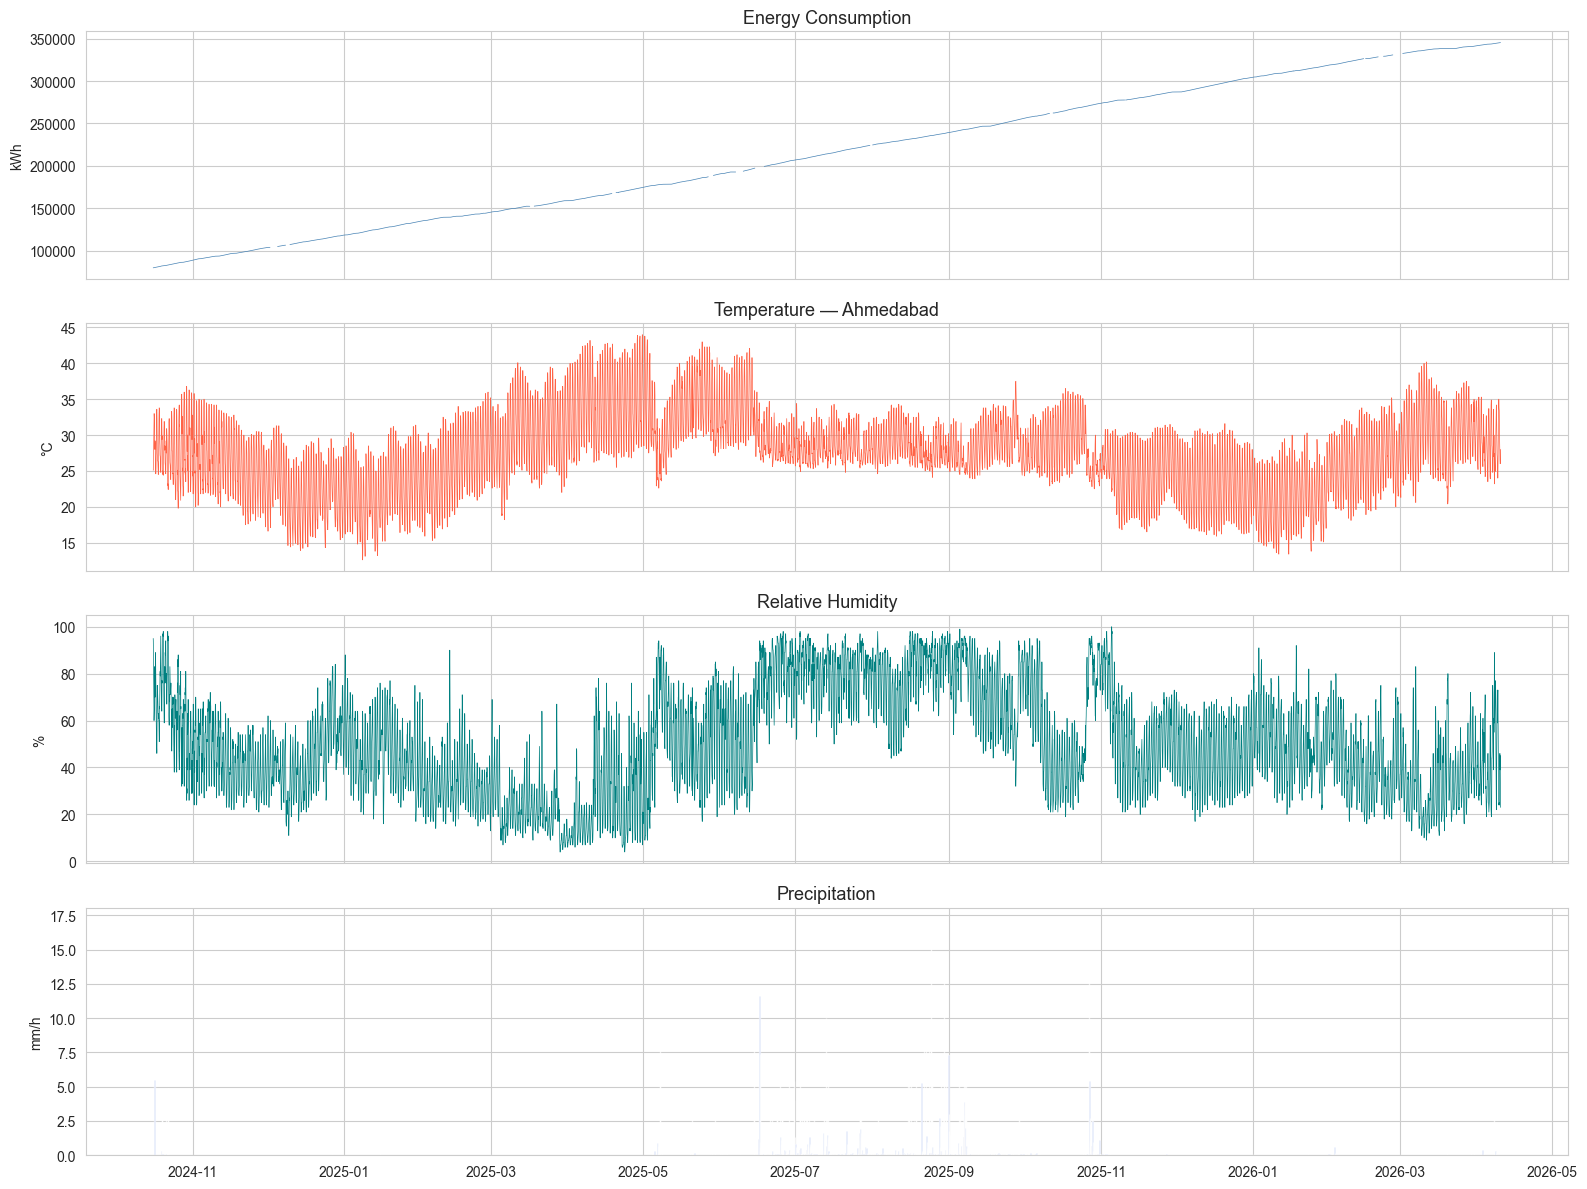

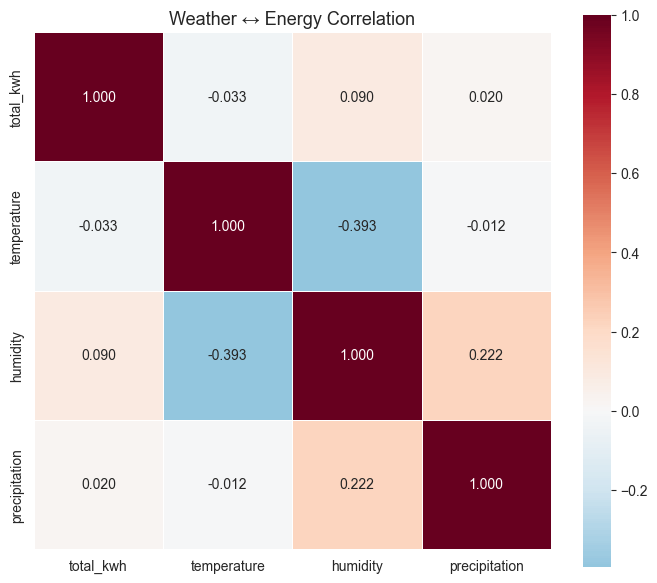

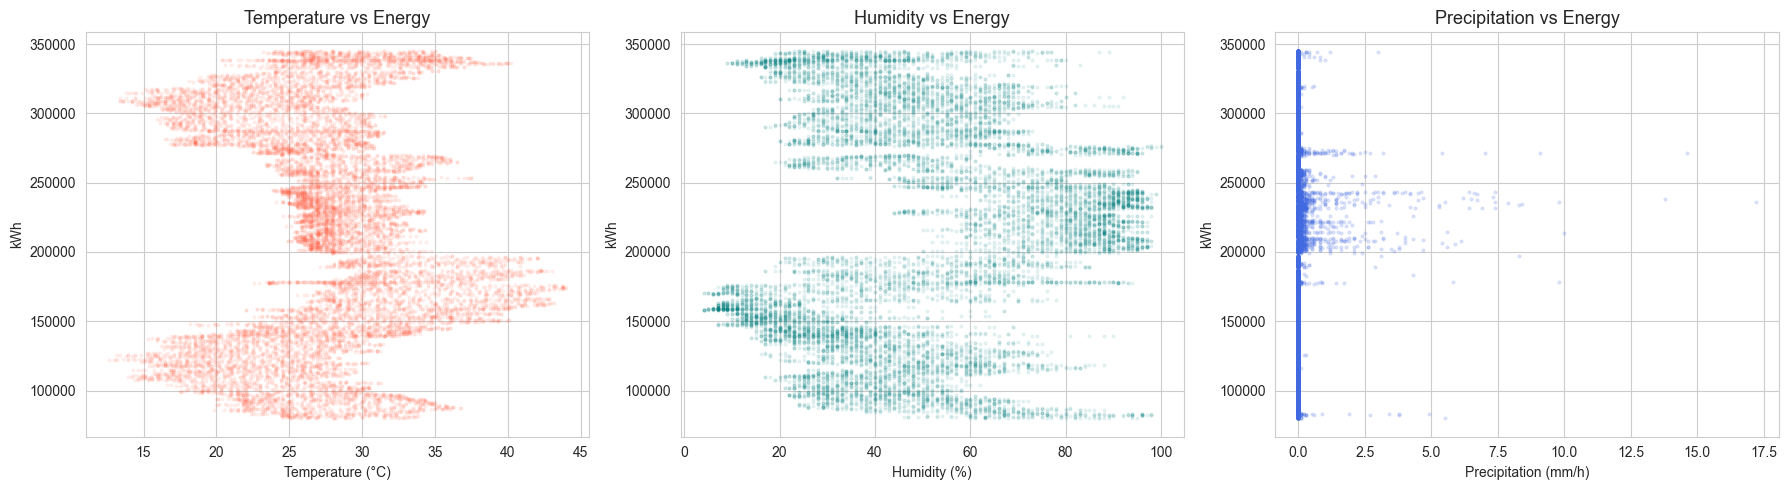

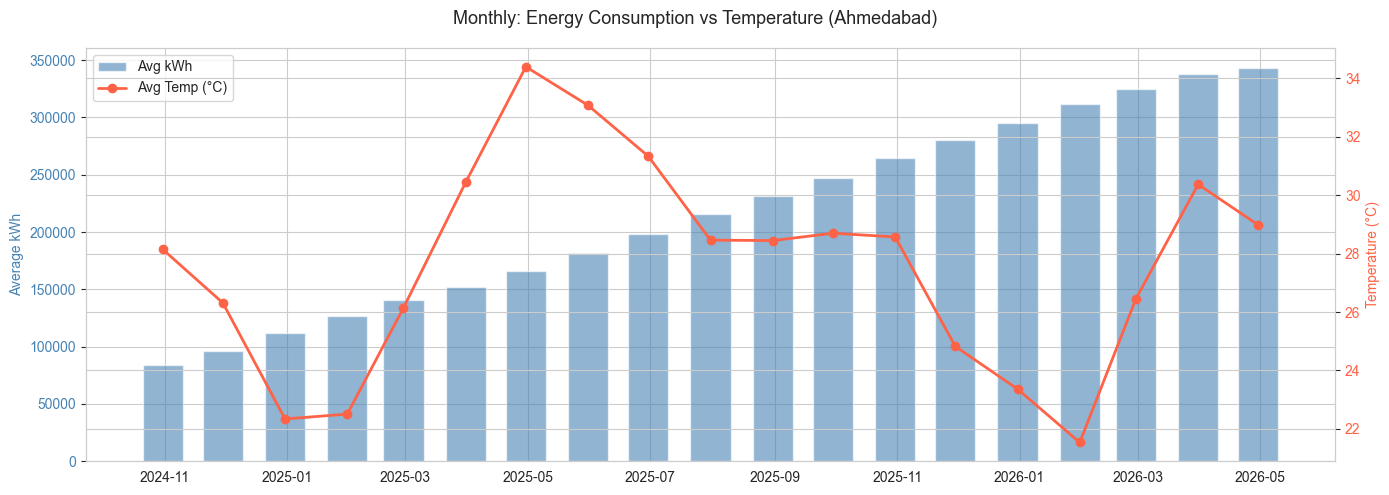

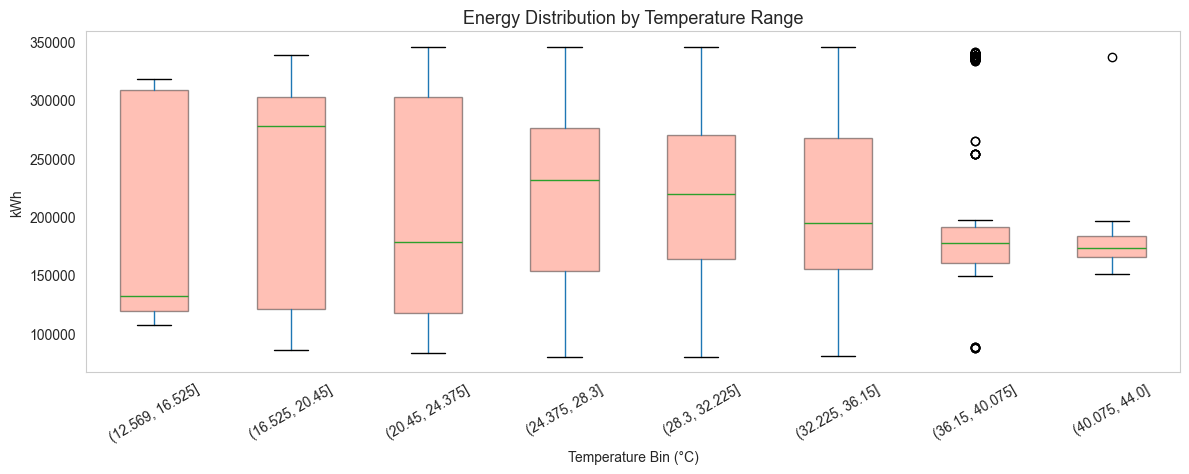

In [9]:
# 1. Time series: energy + weather stacked
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df['rtc_timestamp'], df['total_kwh'], lw=0.5, color='steelblue')
axes[0].set_ylabel('kWh')
axes[0].set_title('Energy Consumption')

axes[1].plot(df['rtc_timestamp'], df['temperature'], lw=0.5, color='tomato')
axes[1].set_ylabel('°C')
axes[1].set_title('Temperature — Ahmedabad')

axes[2].plot(df['rtc_timestamp'], df['humidity'], lw=0.5, color='teal')
axes[2].set_ylabel('%')
axes[2].set_title('Relative Humidity')

axes[3].bar(df['rtc_timestamp'], df['precipitation'], width=0.04,
            color='royalblue', alpha=0.7)
axes[3].set_ylabel('mm/h')
axes[3].set_title('Precipitation')

plt.tight_layout()
plt.show()


# 2. Correlation heatmap
corr_cols = ['total_kwh'] + WEATHER_COLS
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Weather ↔ Energy Correlation')
plt.tight_layout()
plt.show()


# 3. Scatter: each weather variable vs energy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['temperature'], df['total_kwh'], alpha=0.08, s=4, color='tomato')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('kWh')
axes[0].set_title('Temperature vs Energy')

axes[1].scatter(df['humidity'], df['total_kwh'], alpha=0.08, s=4, color='teal')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('kWh')
axes[1].set_title('Humidity vs Energy')

axes[2].scatter(df['precipitation'], df['total_kwh'], alpha=0.15, s=4, color='royalblue')
axes[2].set_xlabel('Precipitation (mm/h)')
axes[2].set_ylabel('kWh')
axes[2].set_title('Precipitation vs Energy')

plt.tight_layout()
plt.show()


# 4. Monthly dual-axis: energy bars + temperature line
monthly = df.set_index('rtc_timestamp').resample('ME').agg(
    kwh_mean=('total_kwh', 'mean'),
    temp_mean=('temperature', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(monthly.index, monthly['kwh_mean'], width=20,
        color='steelblue', alpha=0.6, label='Avg kWh')
ax1.set_ylabel('Average kWh', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['temp_mean'], color='tomato',
         marker='o', lw=2, label='Avg Temp (°C)')
ax2.set_ylabel('Temperature (°C)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

fig.suptitle('Monthly: Energy Consumption vs Temperature (Ahmedabad)', fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()


# 5. Energy distribution by temperature range
df_tmp = df.dropna(subset=['temperature', 'total_kwh']).copy()
df_tmp['temp_bin'] = pd.cut(df_tmp['temperature'], bins=8)

fig, ax = plt.subplots(figsize=(12, 5))
df_tmp.boxplot(column='total_kwh', by='temp_bin', ax=ax, grid=False,
               patch_artist=True, boxprops=dict(facecolor='tomato', alpha=0.4))
ax.set_xlabel('Temperature Bin (°C)')
ax.set_ylabel('kWh')
ax.set_title('Energy Distribution by Temperature Range')
fig.suptitle('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

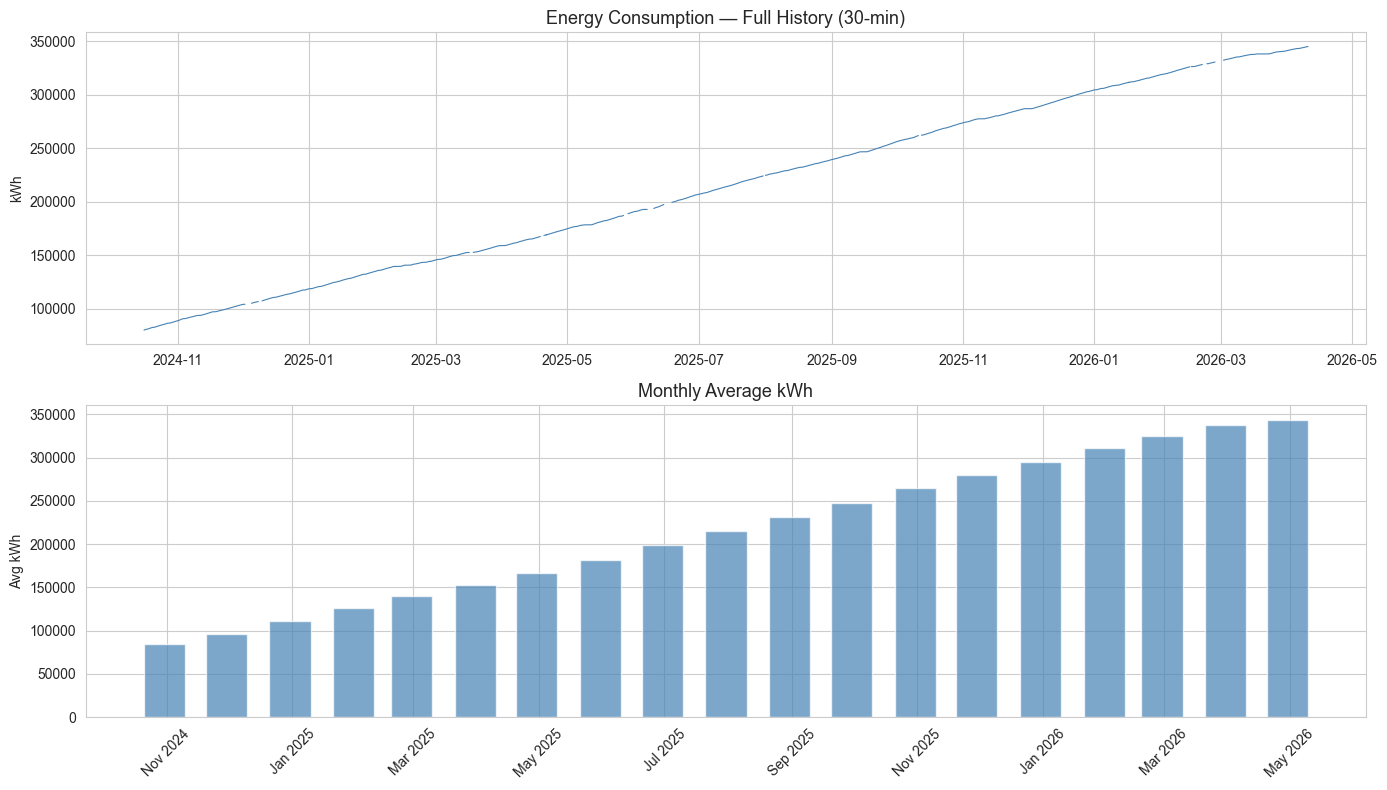

In [10]:
# Plot raw cleaned data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['rtc_timestamp'], df['total_kwh'], linewidth=0.8, color='steelblue')
axes[0].set_title('Energy Consumption — Full History (30-min)')
axes[0].set_ylabel('kWh')

# Monthly averages
monthly = df.set_index('rtc_timestamp')['total_kwh'].resample('ME').mean()
axes[1].bar(monthly.index, monthly.values, width=20, color='steelblue', alpha=0.7)
axes[1].set_title('Monthly Average kWh')
axes[1].set_ylabel('Avg kWh')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Basic stats
print(df['total_kwh'].describe())

# Missing % after resample
full_range = pd.date_range(df['rtc_timestamp'].min(), df['rtc_timestamp'].max(), freq='1h')
missing_pct = (1 - len(df) / len(full_range)) * 100
print(f"\nMissing 1h slots: {missing_pct:.2f}%")

count     12350.000000
mean     215022.002614
std       78897.998557
min       79909.906296
25%      144236.025453
50%      216289.933403
75%      285145.645447
max      345251.152727
Name: total_kwh, dtype: float64

Missing 1h slots: 0.00%


## 4. Feature Engineering

In [12]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Time features
    out['hour_of_day'] = out['rtc_timestamp'].dt.hour
    out['day_of_week'] = out['rtc_timestamp'].dt.dayofweek
    out['month']       = out['rtc_timestamp'].dt.month
    out['year']        = out['rtc_timestamp'].dt.year
    out['is_weekend']  = (out['day_of_week'] >= 5).astype(int)

    # Rolling kWh stats
    out['rolling_max_6']   = out['total_kwh'].rolling(6).max().reset_index(level=0, drop=True)
    out['rolling_min_6']   = out['total_kwh'].rolling(6).min().reset_index(level=0, drop=True)
    out['rolling_range_6'] = out['rolling_max_6'] - out['rolling_min_6']

    # Cyclical encoding (no ordinal bias for periodic features) 
    out['hour_sin'] = np.sin(2 * np.pi * out['hour_of_day'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour_of_day'] / 24)
    out['dow_sin']  = np.sin(2 * np.pi * out['day_of_week'] / 7)
    out['dow_cos']  = np.cos(2 * np.pi * out['day_of_week'] / 7)
    out['mon_sin']  = np.sin(2 * np.pi * out['month'] / 12)
    out['mon_cos']  = np.cos(2 * np.pi * out['month'] / 12)

    # Lag features on kWh
    for lag in [1, 2, 3, 6, 12, 24]:
        out[f'kwh_lag_{lag}'] = out['total_kwh'].shift(lag)

    out['target_diff'] = out['total_kwh'] - out['kwh_lag_1']
    out = out[out['target_diff'].abs() > 1]

    # Rolling stats / diff on kWh
    for w in [3, 6, 24]:
        out[f'kwh_roll_std_{w}'] = out['total_kwh'].rolling(w, min_periods=2).std()
    out['diff_2'] = out['total_kwh'].diff(2)

    # Weather features (raw + lag + 24h rolling mean)
    weather_present = [c for c in WEATHER_COLS if c in out.columns]
    for col in weather_present:
        out[f'{col}_lag_1']        = out[col].shift(1)
        out[f'{col}_lag_24']       = out[col].shift(24)
        out[f'{col}_roll_mean_24'] = out[col].rolling(24, min_periods=1).mean()

    return out


feat_df = build_features(df)
feat_df = feat_df.dropna().reset_index(drop=True)

print(f"Feature df shape: {feat_df.shape}")
feat_df.head()

Feature df shape: (10094, 39)


,rtc_timestamp,total_kwh,temperature,humidity,precipitation,hour_of_day,day_of_week,month,year,is_weekend,rolling_max_6,rolling_min_6,rolling_range_6,hour_sin,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos,kwh_lag_1,kwh_lag_2,kwh_lag_3,kwh_lag_6,kwh_lag_12,kwh_lag_24,target_diff,kwh_roll_std_3,kwh_roll_std_6,kwh_roll_std_24,diff_2,temperature_lag_1,temperature_lag_24,temperature_roll_mean_24,humidity_lag_1,humidity_lag_24,humidity_roll_mean_24,precipitation_lag_1,precipitation_lag_24,precipitation_roll_mean_24
0,2024-10-17 06:00:00,80532.190000,25.0,69,0.0,6,3,10,2024,0,80532.190000,80507.869867,24.320133,1.000000,6.123234e-17,0.433884,-0.900969,-0.866025,0.5,80530.727361,80518.441618,80514.310000,80470.285522,80296.211429,79960.611061,1.462639,7.550903,22.635289,195.801399,13.748382,24.6,25.1,28.829167,79.0,94.0,75.541667,0.0,0.0,0.241667
1,2024-10-17 08:00:00,80534.135556,26.7,66,0.0,8,3,10,2024,0,80534.135556,80514.310000,19.825556,0.866025,-5.000000e-01,0.433884,-0.900969,-0.866025,0.5,80532.190000,80532.190000,80530.727361,80514.310000,80359.513175,80008.227973,1.945556,1.709790,10.893732,191.352322,3.408194,25.0,26.2,28.850000,69.0,87.0,74.666667,0.0,0.0,0.241667
2,2024-10-17 09:00:00,80558.084265,28.4,61,0.0,9,3,10,2024,0,80558.084265,80518.441618,39.642647,0.707107,-7.071068e-01,0.433884,-0.900969,-0.866025,0.5,80534.135556,80532.190000,80532.190000,80514.310000,80385.507463,80040.995915,23.948709,14.421274,15.365897,186.311451,25.894265,26.7,26.8,28.916667,66.0,86.0,73.625000,0.0,0.0,0.241667
3,2024-10-17 10:00:00,80587.470423,30.0,57,0.0,10,3,10,2024,0,80587.470423,80530.727361,56.743061,0.500000,-8.660254e-01,0.433884,-0.900969,-0.866025,0.5,80558.084265,80534.135556,80532.190000,80518.441618,80412.541622,80058.711385,29.386158,26.713589,25.110835,181.901669,53.334867,28.4,28.2,28.991667,61.0,82.0,72.583333,0.0,0.0,0.241667
4,2024-10-17 11:00:00,80618.111644,31.5,53,0.0,11,3,10,2024,0,80618.111644,80532.190000,85.921644,0.258819,-9.659258e-01,0.433884,-0.900969,-0.866025,0.5,80587.470423,80558.084265,80534.135556,80530.727361,80437.611129,80079.124308,30.641221,30.015876,35.873177,178.472768,60.027379,30.0,30.0,29.054167,57.0,76.0,71.625000,0.0,0.0,0.241667


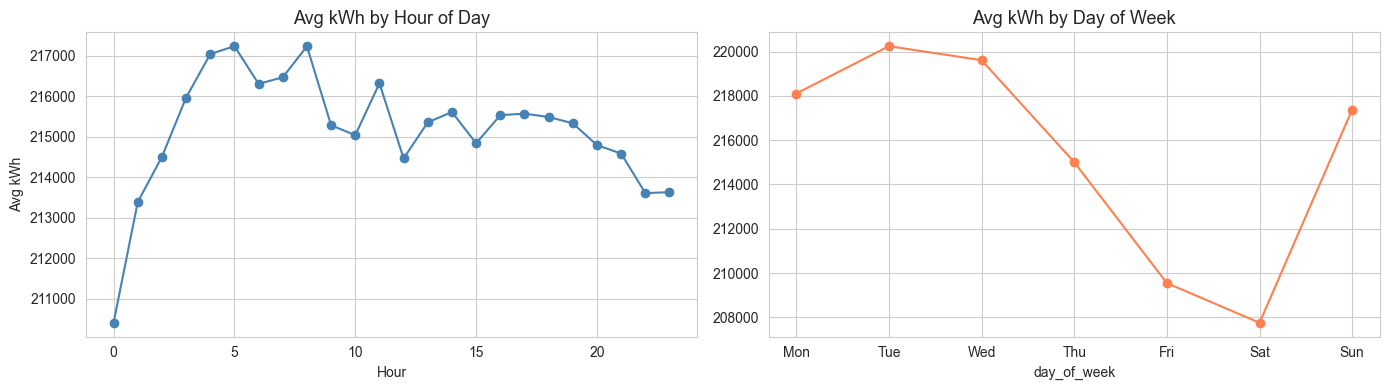

In [13]:
# Hourly & weekly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feat_df.groupby('hour_of_day')['total_kwh'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Avg kWh by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg kWh')

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
feat_df.groupby('day_of_week')['total_kwh'].mean().plot(ax=axes[1], marker='o', color='coral')
axes[1].set_title('Avg kWh by Day of Week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)

plt.tight_layout()
plt.show()

In [14]:
feat_df.columns

Index(['rtc_timestamp', 'total_kwh', 'temperature', 'humidity',
       'precipitation', 'hour_of_day', 'day_of_week', 'month', 'year',
       'is_weekend', 'rolling_max_6', 'rolling_min_6', 'rolling_range_6',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'mon_sin', 'mon_cos',
       'kwh_lag_1', 'kwh_lag_2', 'kwh_lag_3', 'kwh_lag_6', 'kwh_lag_12',
       'kwh_lag_24', 'target_diff', 'kwh_roll_std_3', 'kwh_roll_std_6',
       'kwh_roll_std_24', 'diff_2', 'temperature_lag_1', 'temperature_lag_24',
       'temperature_roll_mean_24', 'humidity_lag_1', 'humidity_lag_24',
       'humidity_roll_mean_24', 'precipitation_lag_1', 'precipitation_lag_24',
       'precipitation_roll_mean_24'],
      dtype='str')

## 5. Train / Test Split

In [17]:
TARGET = 'target_diff'

EXCLUDED = {
    'rtc_timestamp', 'total_kwh', "year", "is_weekend",
    # raw temporal cols — cyclical encodings (sin/cos) are used instead
    'hour_of_day', 'day_of_week', 'month',
    # 'year' is kept as a numeric trend feature (limited extrapolation power,
    # but useful for capturing slow demand growth across years)
    'kwh_roll_mean_3', 'kwh_roll_mean_6', 'kwh_roll_mean_24', 'target_diff'
}

model_features = [c for c in feat_df.columns if c not in EXCLUDED]

# Chronological 80/20 split
split_idx = int(len(feat_df) * 0.8)
train_df  = feat_df.iloc[:split_idx].copy()
test_df   = feat_df.iloc[split_idx:].copy()

X_train = train_df[model_features]
y_train = train_df[TARGET]
X_test  = test_df[model_features]
y_test  = test_df[TARGET]

print(f"Train: {train_df['rtc_timestamp'].min()} → {train_df['rtc_timestamp'].max()} | {len(train_df):,} rows")
print(f"Test:  {test_df['rtc_timestamp'].min()} → {test_df['rtc_timestamp'].max()} | {len(test_df):,} rows")
print(f"Features: {len(model_features)}")

Train: 2024-10-17 06:00:00 → 2025-12-16 22:00:00 | 8,075 rows
Test:  2025-12-16 23:00:00 → 2026-04-10 08:00:00 | 2,019 rows
Features: 31


In [18]:
X_train.nunique().sort_values()

dow_cos                          7
dow_sin                          7
mon_cos                         11
mon_sin                         11
hour_sin                        21
hour_cos                        22
precipitation                   70
precipitation_lag_1             70
precipitation_lag_24            70
humidity_lag_24                 97
humidity_lag_1                  97
humidity                        97
temperature                    301
temperature_lag_1              301
temperature_lag_24             301
precipitation_roll_mean_24     742
humidity_roll_mean_24         1830
temperature_roll_mean_24      4096
kwh_lag_24                    7231
kwh_lag_12                    7518
kwh_lag_6                     7785
rolling_min_6                 7832
kwh_lag_3                     7937
kwh_lag_2                     8009
kwh_lag_1                     8075
rolling_range_6               8075
rolling_max_6                 8075
kwh_roll_std_6                8075
kwh_roll_std_24     

In [19]:
y_train.describe()

count    8075.000000
mean       24.979383
std         8.075414
min         1.000145
25%        20.335697
50%        24.148706
75%        30.173969
max        63.685547
Name: target_diff, dtype: float64

## 6. XGBoost Model — Short-term Forecasting

In [20]:
# explicitly define which columns go into the model
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features

['temperature',
 'humidity',
 'precipitation',
 'rolling_max_6',
 'rolling_min_6',
 'rolling_range_6',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'mon_sin',
 'mon_cos',
 'kwh_lag_1',
 'kwh_lag_2',
 'kwh_lag_3',
 'kwh_lag_6',
 'kwh_lag_12',
 'kwh_lag_24',
 'kwh_roll_std_3',
 'kwh_roll_std_6',
 'kwh_roll_std_24',
 'diff_2',
 'temperature_lag_1',
 'temperature_lag_24',
 'temperature_roll_mean_24',
 'humidity_lag_1',
 'humidity_lag_24',
 'humidity_roll_mean_24',
 'precipitation_lag_1',
 'precipitation_lag_24',
 'precipitation_roll_mean_24']

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features)
    ],
    remainder='drop' # Drops unused columns
)

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=800,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
    ))
])

xgb_model.fit(X_train, y_train)
print('XGBoost training complete')

XGBoost training complete


In [22]:
# Predictions
delta_pred = xgb_model.predict(X_test)
y_pred = X_test['kwh_lag_1'].values + delta_pred
y_pred = pd.DataFrame(y_pred, columns=['total_kwh'], index=X_test.index)
y_pred.head()

,total_kwh
8075,295859.090856
8076,295890.982035
8077,295922.633922
8078,295954.895776
8079,295989.190888


In [23]:
# Metrics
def regression_metrics(actual: pd.DataFrame, predicted: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in actual.columns:
        mae = mean_absolute_error(actual[col], predicted[col])
        rmse = root_mean_squared_error(actual[col], predicted[col])
        mape = np.mean(np.abs((actual[col] - predicted[col]) / np.clip(actual[col], 1e-6, None))) * 100
        rows.append({'target': col, 'MAE': mae, 'RMSE': rmse, 'MAPE_pct': mape})
    return pd.DataFrame(rows).sort_values('RMSE')

y_test_actual = test_df['total_kwh'].loc[X_test.index]
metrics_df = regression_metrics(y_test_actual.to_frame(), y_pred)
metrics_df

,target,MAE,RMSE,MAPE_pct
0,total_kwh,1.806664,2.663657,0.000562


## 7. Plots — Training, Testing, Residuals

In [24]:
# Reconstruct predictions for plotting
delta_train = xgb_model.predict(X_train)
y_train_reconstructed = X_train['kwh_lag_1'].values + delta_train

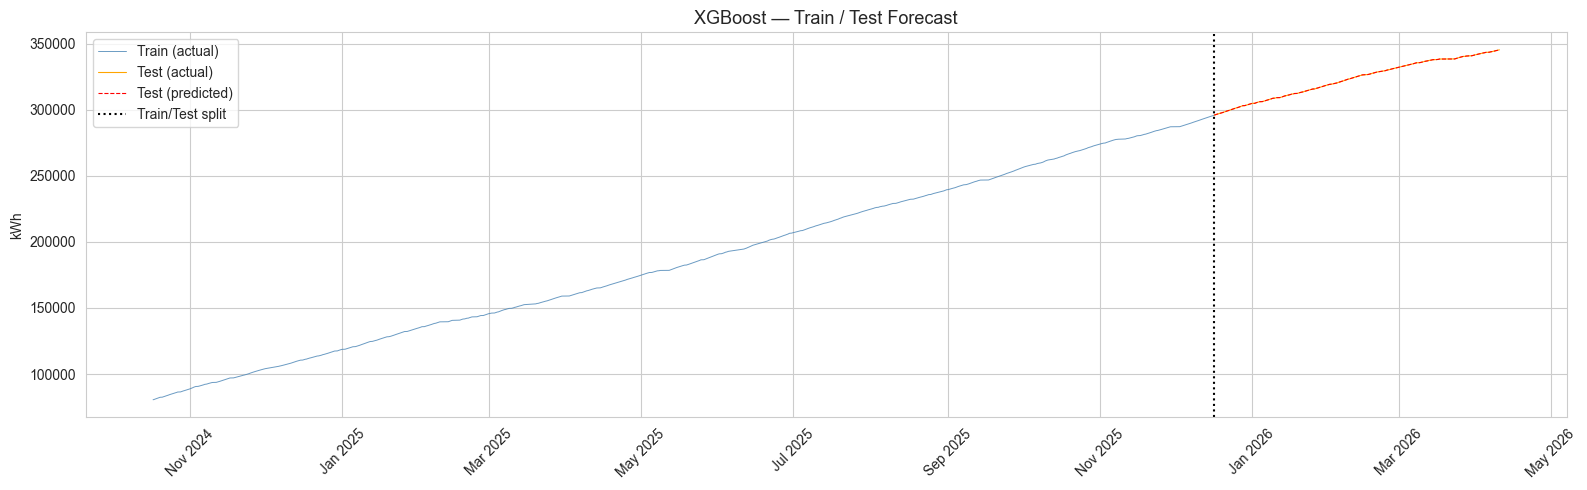

In [25]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_df['rtc_timestamp'], y_train_reconstructed,          # ← reconstructed, not y_train
        label='Train (actual)', color='steelblue', linewidth=0.7, alpha=0.8)
ax.plot(test_df['rtc_timestamp'], y_test_actual.values,
        label='Test (actual)', color='orange', linewidth=0.8)
ax.plot(test_df['rtc_timestamp'], y_pred['total_kwh'].values,
        label='Test (predicted)', color='red', linewidth=0.8, linestyle='--')
ax.axvline(test_df['rtc_timestamp'].iloc[0], color='black', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('XGBoost — Train / Test Forecast')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

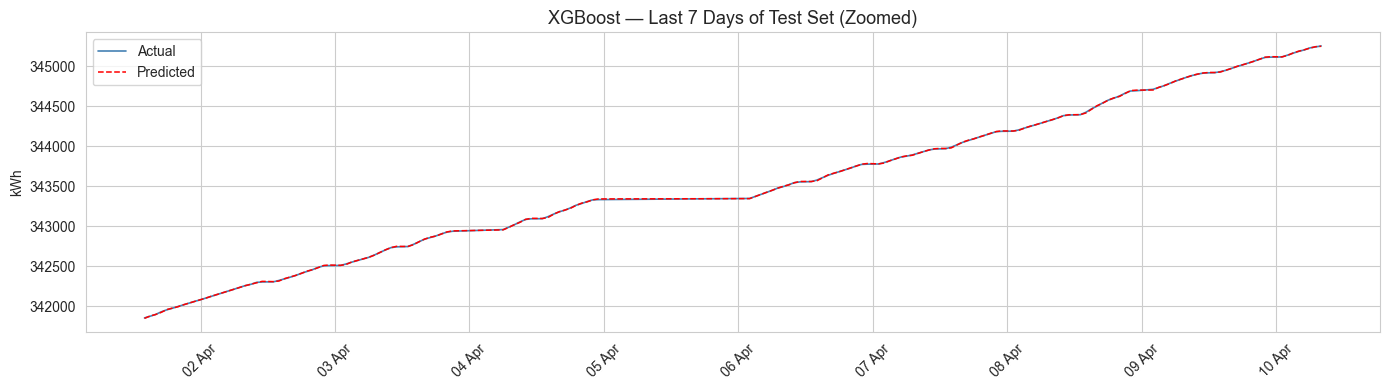

In [26]:
# Zoom into last 7 days of test
last7 = test_df.tail(24 * 7)   # 24 steps/day for 1h intervals, not 96
pred_last7 = y_pred['total_kwh'].iloc[-len(last7):]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last7['rtc_timestamp'], last7['total_kwh'],      
        label='Actual', color='steelblue', linewidth=1.2)
ax.plot(last7['rtc_timestamp'], pred_last7.values,      
        label='Predicted', color='red', linewidth=1.1, linestyle='--')
ax.set_title('XGBoost — Last 7 Days of Test Set (Zoomed)')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

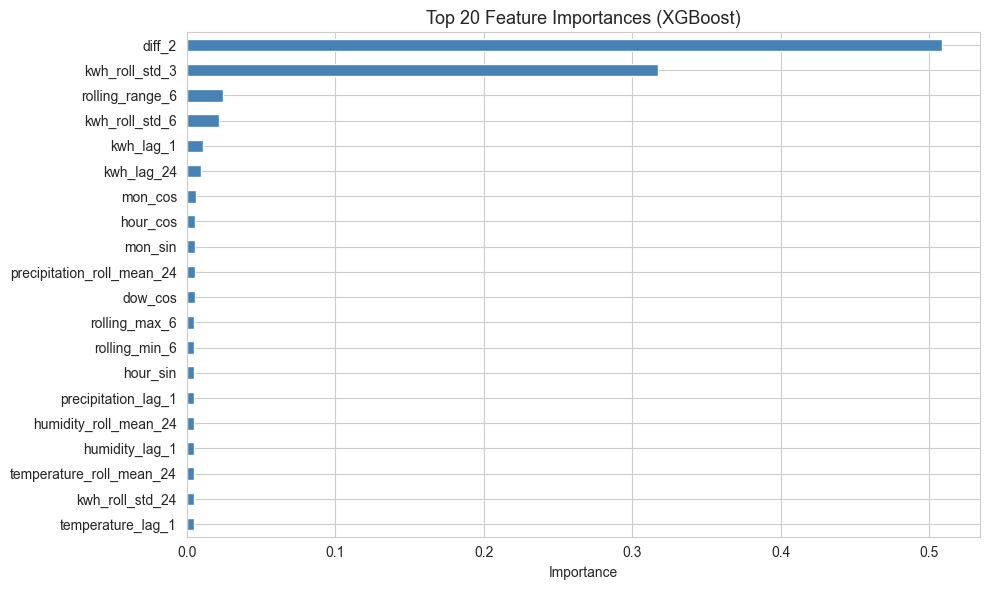

In [27]:
# Feature Importance
booster = xgb_model.named_steps['model']
feat_imp = pd.Series(booster.feature_importances_, index=model_features)
top20 = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Anomaly Detection

In [28]:
results = test_df[['rtc_timestamp', 'total_kwh']].copy()
results['predicted'] = y_pred['total_kwh'].values        # y_pred is a DataFrame
results['residual'] = results['total_kwh'] - results['predicted']
resid_std = results['residual'].std()
results['z_score'] = results['residual'] / resid_std

# Isolation Forest on residuals
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
results['iso_flag']  = iso.fit_predict(results[['residual']])
results['iso_score'] = iso.decision_function(results[['residual']])

# Rule-based: |z| > 3
results['rule_flag'] = (results['z_score'].abs() > 3).astype(int)
results['anomaly']   = ((results['iso_flag'] == -1) | (results['rule_flag'] == 1)).astype(int)
results['severity']  = results['z_score'].abs().round(3)

anomalies = results[results['anomaly'] == 1].sort_values('severity', ascending=False)
print(f"Anomalies detected: {len(anomalies)} / {len(results)} ({100*len(anomalies)/len(results):.1f}%)")
anomalies.head(10)

Anomalies detected: 60 / 2019 (3.0%)


,rtc_timestamp,total_kwh,predicted,residual,z_score,iso_flag,iso_score,rule_flag,anomaly,severity
8719,2026-01-17 11:00:00,311811.068125,311831.458300,-20.390175,-7.668240,-1,-0.147171,1,1,7.668
9348,2026-02-16 23:00:00,326715.920000,326731.290657,-15.370657,-5.780524,-1,-0.140916,1,1,5.781
8720,2026-01-17 12:00:00,311835.168788,311849.791811,-14.623023,-5.499357,-1,-0.135517,1,1,5.499
9343,2026-02-16 18:00:00,326652.692424,326664.921947,-12.229523,-4.599221,-1,-0.121066,1,1,4.599
9438,2026-02-23 21:00:00,329685.318052,329673.544661,11.773391,4.427681,-1,-0.108023,1,1,4.428
9439,2026-02-23 22:00:00,329703.890140,329715.537064,-11.646924,-4.380120,-1,-0.119746,1,1,4.380
9987,2026-04-04 14:00:00,343118.978824,343108.310209,10.668614,4.012202,-1,-0.104912,1,1,4.012
9383,2026-02-18 12:00:00,327591.951744,327602.345545,-10.393801,-3.908851,-1,-0.104600,1,1,3.909
8682,2026-01-15 12:00:00,310898.097538,310908.463632,-10.366094,-3.898432,-1,-0.103566,1,1,3.898
9203,2026-02-08 18:00:00,323138.560000,323148.665677,-10.105677,-3.800495,-1,-0.097137,1,1,3.800


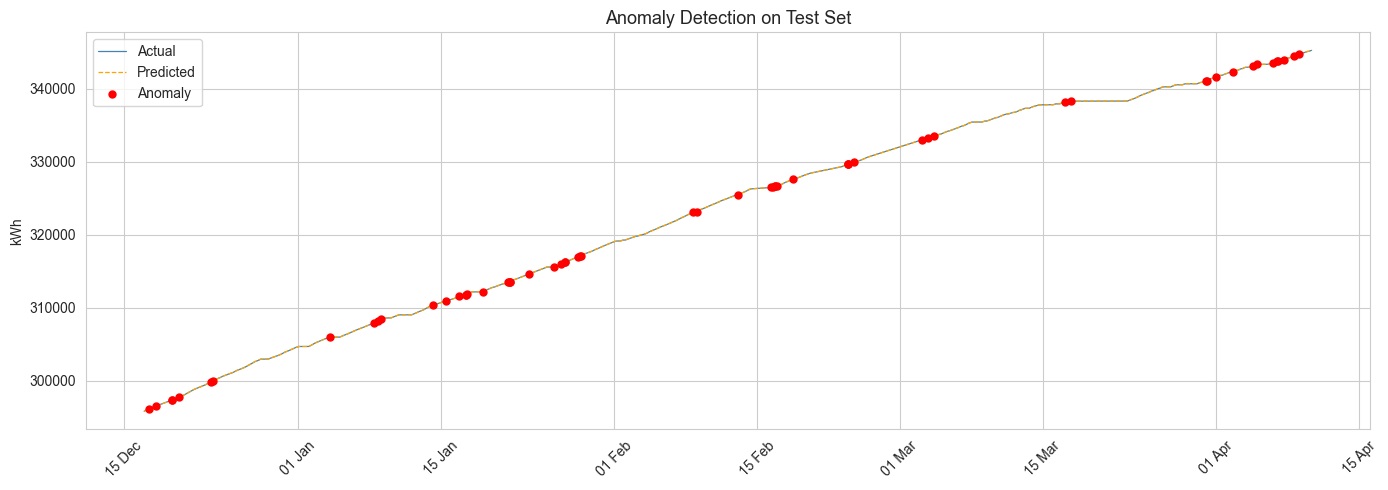

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results['rtc_timestamp'], results['total_kwh'], label='Actual', linewidth=0.9, color='steelblue')
ax.plot(results['rtc_timestamp'], results['predicted'], label='Predicted', linewidth=0.9, color='orange', linestyle='--')
ax.scatter(anomalies['rtc_timestamp'], anomalies['total_kwh'], color='red', s=25, zorder=5, label='Anomaly')
ax.set_title('Anomaly Detection on Test Set')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Save XGBoost Model

In [30]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(xgb_model, f"{MODEL_DIR}/xgb_energy_model.pkl")
joblib.dump(model_features, f"{MODEL_DIR}/model_features.pkl")

print('XGBoost model saved.')

XGBoost model saved.


## 10. PENDING FROM HERE: N-HiTS - Long-term Future Forecasting (May 2026)

> **N-HiTS** (Neural Hierarchical Interpolation for Time Series) is designed for long-horizon forecasting.  
> It predicts the full future window in **one shot** — no recursive error accumulation.

In [31]:

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE

FORECAST_HORIZON = 24 * 31    # 31 days × 24h = 744 steps  (was 96*31 = wrong, 15-min)
INPUT_SIZE = 24 * 14    # look back 2 weeks = 336h    (was 96*14)

nf_df = df[['rtc_timestamp', 'total_kwh'] + WEATHER_COLS].copy()
nf_df = nf_df.dropna(subset=['rtc_timestamp', 'total_kwh'])
nf_df.loc[nf_df['total_kwh'] == 0, 'total_kwh'] = np.nan

nf_df = nf_df.rename(columns={'rtc_timestamp': 'ds', 'total_kwh': 'y'})
nf_df['unique_id'] = METER_ID
nf_df = nf_df[['unique_id', 'ds', 'y'] + WEATHER_COLS]

print(f"NeuralForecast df shape: {nf_df.shape}")
nf_df.head()

2026-04-22 18:32:08,944	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-22 18:32:09,718	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


NeuralForecast df shape: (12350, 6)


,unique_id,ds,y,temperature,humidity,precipitation
0,FUTU0000000004000002,2024-10-16 04:00:00,79909.906296,25.1,95,0.0
1,FUTU0000000004000002,2024-10-16 05:00:00,79932.895857,25.1,94,0.0
2,FUTU0000000004000002,2024-10-16 06:00:00,79960.611061,26.2,87,0.0
3,FUTU0000000004000002,2024-10-16 07:00:00,79978.275606,26.8,86,0.0
4,FUTU0000000004000002,2024-10-16 08:00:00,80008.227973,28.2,82,0.0


In [32]:
# Train / val split for NeuralForecast (last HORIZON rows as validation)
nf_train = nf_df.iloc[:-FORECAST_HORIZON].copy()
nf_val   = nf_df.iloc[-FORECAST_HORIZON:].copy()

print(f"NF Train: {nf_train['ds'].min()} → {nf_train['ds'].max()}")
print(f"NF Val: {nf_val['ds'].min()} → {nf_val['ds'].max()}")

NF Train: 2024-10-16 04:00:00 → 2026-03-10 08:00:00
NF Val: 2026-03-10 09:00:00 → 2026-04-10 08:00:00


In [33]:
nhits = NHITS(
    h=FORECAST_HORIZON,
    input_size=INPUT_SIZE,
    loss=MAE(),
    max_steps=1000,
    batch_size=32,
    early_stop_patience_steps=0,
    val_check_steps=50,
    scaler_type='standard',
    n_freq_downsample=[24, 4, 1],
    # Weather as historical exogenous: the model sees weather patterns in the
    # lookback window. We use hist_exog (not futr_exog) because reliable
    # weather forecasts are only ~16 days, but our horizon is 31 days.
    hist_exog_list=WEATHER_COLS,
)

nf = NeuralForecast(models=[nhits], freq='h')   # was '15min' — wrong
nf.fit(df=nf_train, val_size=FORECAST_HORIZON)
print('N-HiTS training complete')

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 4.8 M  | train | 0    
---------------------------------------------------------------
4.8 M     Trainable params
0         Non-trainable params
4.8 M     Total params
19.007    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  4.96it/s, v_num=6, train_loss_step=0.0423, train_loss_epoch=0.0423, valid_loss=1.39e+3]

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  4.89it/s, v_num=6, train_loss_step=0.0423, train_loss_epoch=0.0423, valid_loss=1.39e+3]
N-HiTS training complete


In [34]:
# Validate on held-out period
val_preds = nf.predict()
val_preds.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 200.00it/s]


,unique_id,ds,NHITS
0,FUTU0000000004000002,2026-03-10 09:00:00,335875.59375
1,FUTU0000000004000002,2026-03-10 10:00:00,335916.75000
2,FUTU0000000004000002,2026-03-10 11:00:00,335962.62500
3,FUTU0000000004000002,2026-03-10 12:00:00,336011.87500
4,FUTU0000000004000002,2026-03-10 13:00:00,336084.56250


In [35]:
# Validation metrics
merged = nf_val.merge(val_preds[['unique_id', 'ds', 'NHITS']], on=['unique_id', 'ds'], how='inner')

nhits_mae  = mean_absolute_error(merged['y'], merged['NHITS'])
nhits_rmse = root_mean_squared_error(merged['y'], merged['NHITS'])
nhits_mape = np.mean(np.abs((merged['y'] - merged['NHITS']) / np.clip(merged['y'], 1e-6, None))) * 100

print(f"N-HiTS Validation MAE : {nhits_mae:.4f} kWh")
print(f"N-HiTS Validation RMSE : {nhits_rmse:.4f} kWh")
print(f"N-HiTS Validation MAPE : {nhits_mape:.2f}%")

N-HiTS Validation MAE : 9380.6034 kWh
N-HiTS Validation RMSE : 11177.9337 kWh
N-HiTS Validation MAPE : 2.75%


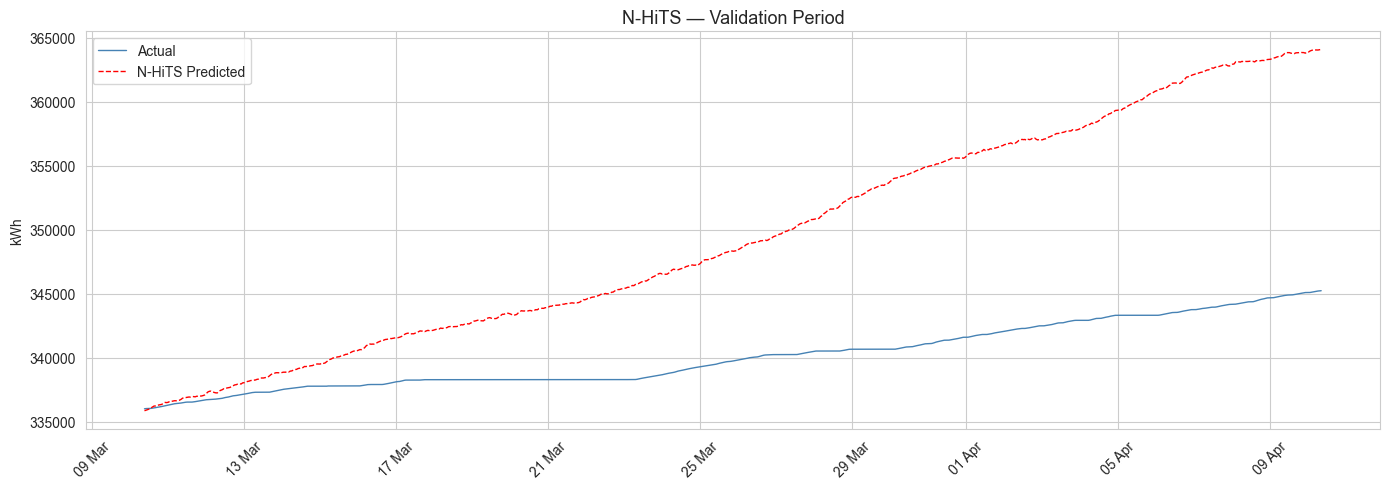

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['ds'], merged['y'], label='Actual', color='steelblue', linewidth=1)
ax.plot(merged['ds'], merged['NHITS'], label='N-HiTS Predicted', color='red', linewidth=1, linestyle='--')
ax.set_title('N-HiTS — Validation Period')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Forecast Future — May 2026

In [195]:
# Retrain on FULL data before forecasting future
nf_full = NeuralForecast(models=[nhits], freq='h')  
nf_full.fit(df=nf_df)

future_forecast = nf_full.predict()
future_forecast = future_forecast.rename(columns={'NHITS': 'forecast_kwh'})
future_forecast['forecast_kwh'] = future_forecast['forecast_kwh'].clip(lower=0)

print(f"Future forecast: {future_forecast['ds'].min()} → {future_forecast['ds'].max()}")
future_forecast.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.7 M  | train | 0    
---------------------------------------------------------------
3.7 M     Trainable params
0         Non-trainable params
3.7 M     Total params
14.878    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  8.03it/s, v_num=4, train_loss_step=0.298, train_loss_epoch=0.298]

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  7.90it/s, v_num=4, train_loss_step=0.298, train_loss_epoch=0.298]

GPU available: False, used: False


TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 199.89it/s]
Future forecast: 2026-04-10 09:00:00 → 2026-05-11 08:00:00


,unique_id,ds,forecast_kwh
0,FUTU0000000004000002,2026-04-10 09:00:00,345308.25000
1,FUTU0000000004000002,2026-04-10 10:00:00,345294.56250
2,FUTU0000000004000002,2026-04-10 11:00:00,345329.21875
3,FUTU0000000004000002,2026-04-10 12:00:00,345337.03125
4,FUTU0000000004000002,2026-04-10 13:00:00,345378.37500


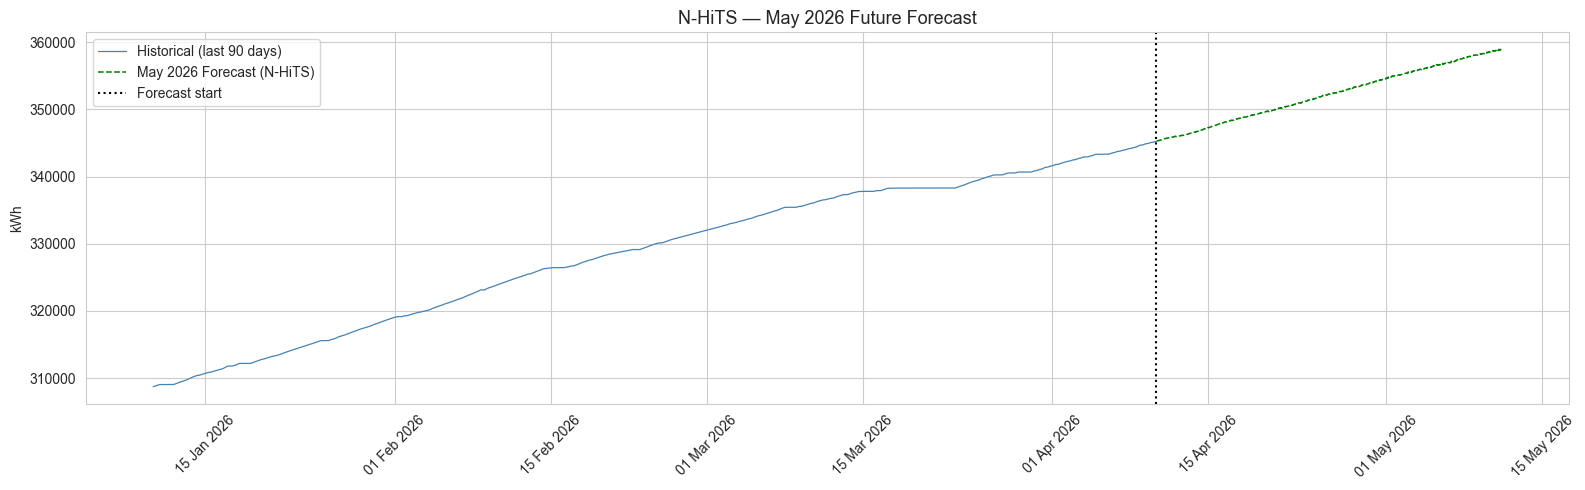

In [196]:
# Plot: history + future forecast
last_90d = nf_df[nf_df['ds'] >= nf_df['ds'].max() - pd.Timedelta(days=90)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(last_90d['ds'], last_90d['y'], label='Historical (last 90 days)', color='steelblue', linewidth=0.9)
ax.plot(future_forecast['ds'], future_forecast['forecast_kwh'],
        label='May 2026 Forecast (N-HiTS)', color='green', linewidth=1.1, linestyle='--')
ax.axvline(nf_df['ds'].max(), color='black', linewidth=1.5, linestyle=':', label='Forecast start')
ax.set_title('N-HiTS — May 2026 Future Forecast')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

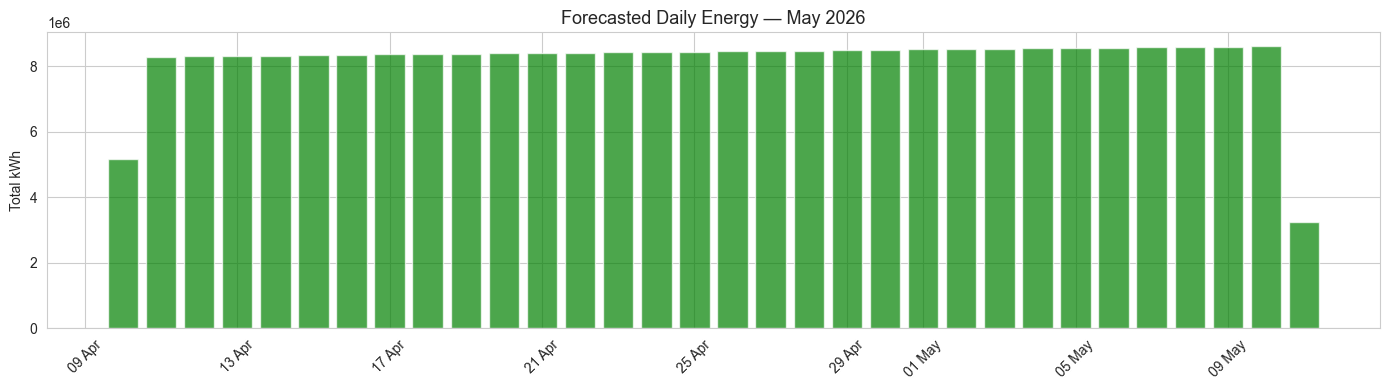

Total forecasted energy for May 2026: 262044512.00 kWh


In [197]:
# Daily aggregated forecast for May
daily_forecast = (
    future_forecast.set_index('ds')['forecast_kwh']
    .resample('D').sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_forecast['ds'], daily_forecast['forecast_kwh'], color='green', alpha=0.7, width=0.8)
ax.set_title('Forecasted Daily Energy — May 2026')
ax.set_ylabel('Total kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total forecasted energy for May 2026: {daily_forecast['forecast_kwh'].sum():.2f} kWh")

In [198]:
# Compare model summaries
summary = pd.DataFrame([
    {'Model': 'XGBoost (1-step)', 'MAE': metrics_df["MAE"], 'RMSE': metrics_df["RMSE"], 'MAPE%': metrics_df["MAPE_pct"],
     'Use case': 'Next 1h to 1-2 days'},           
    {'Model': 'N-HiTS', 'MAE': nhits_mae, 'RMSE': nhits_rmse, 'MAPE%': nhits_mape,
     'Use case': 'Next 1 month (May 2026)'}
])
summary.round(4)

,Model,MAE,RMSE,MAPE%,Use case
0,XGBoost (1-step),"0 1.846042 Name: MAE, dtype: float64","0 2.718667 Name: RMSE, dtype: float64","0 0.000574 Name: MAPE_pct, dtype: float64",Next 1h to 1-2 days
1,N-HiTS,8800.972151,10087.989154,2.57743,Next 1 month (May 2026)


In [199]:
# Save future forecast
future_forecast.to_csv(f"{MODEL_DIR}/may_2026_forecast.csv", index=False)
nf_full.save(f"{MODEL_DIR}/nhits_model", overwrite=True)
print('N-HiTS model and forecast saved.')

N-HiTS model and forecast saved.


## 12. XGBoost Recursive - Short-term Future (1–2 days ahead)

> Use this for next-day operations where accuracy matters more than horizon length.

In [ ]:
def forecast_recursive(model, history_df: pd.DataFrame, steps: int = 24,
                       future_weather: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Recursive 1-step-at-a-time XGBoost forecasting.

    Parameters
    ----------
    model         : fitted pipeline that predicts `target_diff` (Δ kWh).
    history_df    : continuous hourly DataFrame with at least
                    ['rtc_timestamp', 'total_kwh'] and any weather cols.
    steps         : number of 1-hour steps to forecast.
    future_weather: optional DataFrame with ['rtc_timestamp', <weather cols>]
                    covering the forecast horizon. If None, real forecast
                    weather is fetched from Open-Meteo for Ahmedabad.
    """
    base_cols = ['rtc_timestamp', 'total_kwh']
    weather_present = [c for c in WEATHER_COLS if c in history_df.columns]
    history = history_df[base_cols + weather_present].copy().reset_index(drop=True)

    last_ts = history['rtc_timestamp'].iloc[-1]
    future_ts = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=steps, freq='1h')

    # Fetch real weather forecast from Open-Meteo if not supplied
    if weather_present:
        if future_weather is None:
            future_weather = fetch_forecast_weather(future_ts[0], steps)
        future_weather = future_weather.set_index('rtc_timestamp')

    preds = []

    for next_ts in future_ts:
        row = {}

        # Temporal features (must match build_features)
        row['hour_sin']   = np.sin(2 * np.pi * next_ts.hour / 24)
        row['hour_cos']   = np.cos(2 * np.pi * next_ts.hour / 24)
        row['dow_sin']    = np.sin(2 * np.pi * next_ts.dayofweek / 7)
        row['dow_cos']    = np.cos(2 * np.pi * next_ts.dayofweek / 7)
        row['mon_sin']    = np.sin(2 * np.pi * next_ts.month / 12)
        row['mon_cos']    = np.cos(2 * np.pi * next_ts.month / 12)
        row['is_weekend'] = int(next_ts.dayofweek >= 5)
        row['year']       = next_ts.year

        # kWh lag features
        for lag in [1, 2, 3, 6, 12, 24]:
            row[f'kwh_lag_{lag}'] = (
                history['total_kwh'].iloc[-lag] if lag <= len(history) else np.nan
            )

        # kWh rolling stats / windowed range
        last6 = history['total_kwh'].iloc[-6:]
        row['rolling_max_6']   = last6.max()
        row['rolling_min_6']   = last6.min()
        row['rolling_range_6'] = row['rolling_max_6'] - row['rolling_min_6']
        for w in [3, 6, 24]:
            row[f'kwh_roll_std_{w}'] = history['total_kwh'].iloc[-w:].std()
        row['diff_2'] = history['total_kwh'].iloc[-1] - history['total_kwh'].iloc[-3]

        # Weather features (current + lag + 24h rolling mean)
        for col in weather_present:
            cur_val = float(future_weather.loc[next_ts, col])
            row[col] = cur_val
            row[f'{col}_lag_1']  = history[col].iloc[-1]
            row[f'{col}_lag_24'] = (
                history[col].iloc[-24] if 24 <= len(history) else history[col].iloc[0]
            )
            recent = history[col].iloc[-23:].tolist() + [cur_val]
            row[f'{col}_roll_mean_24'] = float(np.mean(recent))

        # Predict Δ kWh and reconstruct absolute kWh
        X_row     = pd.DataFrame([row]).reindex(columns=model_features)
        delta     = float(model.predict(X_row)[0])
        last_kwh  = float(history['total_kwh'].iloc[-1])
        pred_kwh  = max(last_kwh + delta, 0.0)

        preds.append({'rtc_timestamp': next_ts, 'total_kwh': pred_kwh})

        # Append to rolling history for next step's lag/rolling
        new_row = {'rtc_timestamp': next_ts, 'total_kwh': pred_kwh}
        for col in weather_present:
            new_row[col] = float(future_weather.loc[next_ts, col])
        history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    return pd.DataFrame(preds)


# Forecast next 48 hours (fetches real weather forecast from Open-Meteo)
next_48h = forecast_recursive(xgb_model, df, steps=24 * 2)  

fig, ax = plt.subplots(figsize=(14, 4))
last_3d = feat_df.tail(24 * 3)                                    
ax.plot(last_3d['rtc_timestamp'], last_3d['total_kwh'], label='Historical (last 3 days)', color='steelblue')
ax.plot(next_48h['rtc_timestamp'], next_48h['total_kwh'], label='XGBoost Next 48h', color='red', linestyle='--')
ax.axvline(feat_df['rtc_timestamp'].iloc[-1], color='black', linestyle=':', linewidth=1.5)
ax.set_title('XGBoost Recursive — Next 48 Hours')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()